# 1.Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.figure_factory as ff

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import IFrame
import seaborn as sns
import numpy as np

%matplotlib inline

# 2.Load and Explore Datasets

In [2]:
df = pd.read_csv(r"C:\Users\telug\Downloads\Unemployment in India.csv")
df_2020 = pd.read_csv(r"C:\Users\telug\Downloads\Unemployment_Rate_upto_11_2020.csv")
df.head(10)
df_2020.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74
5,Andhra Pradesh,30-06-2020,M,3.31,19805400,47.41,South,15.9129,79.74
6,Andhra Pradesh,31-07-2020,M,8.34,15431615,38.91,South,15.9129,79.74
7,Andhra Pradesh,31-08-2020,M,6.96,15251776,37.83,South,15.9129,79.74
8,Andhra Pradesh,30-09-2020,M,6.40,15220312,37.47,South,15.9129,79.74
9,Andhra Pradesh,31-10-2020,M,6.59,15157557,37.34,South,15.9129,79.74


# 3.Dataset Information and Structure

In [3]:
df.info()
print("\n" + "="*80 + "\n")
df_2020.info()
print("\n" + "="*80 + "\n")
print(df.describe())
print("\n" + "="*80 + "\n")
print(df_2020.describe())
print("\n" + "="*80 + "\n")
print(f"Main dataset shape: {df.shape}")
print(f"2020 dataset shape: {df_2020.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                

# 4.Data Cleaning and Preprocessing

In [4]:
df.columns = df.columns.str.strip()
df_2020.columns = df_2020.columns.str.strip()

In [5]:
df['Date'] = df['Date'].astype(str).str.strip()
df_2020['Date'] = df_2020['Date'].astype(str).str.strip()

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df_2020['Date'] = pd.to_datetime(df_2020['Date'], format='%d-%m-%Y', errors='coerce')

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Month_int'] = df['Date'].dt.month
df['Month'] = df['Date'].dt.strftime('%B')
df = df.drop('Frequency', axis=1)

df_2020['Date'] = pd.to_datetime(df_2020['Date'], format='%d-%m-%Y')
df_2020['Month_int'] = df_2020['Date'].dt.month
df_2020['Month'] = df_2020['Date'].dt.strftime('%B')
df_2020 = df_2020.drop(['Frequency', 'Region.1', 'longitude', 'latitude'], axis=1)

print("Cleaned main dataset:")
print(df.head())
print("\n" + "="*80 + "\n")
print("Cleaned 2020 dataset:")
print(df_2020.head())

Cleaned main dataset:
           Region       Date  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31                             3.65   
1  Andhra Pradesh 2019-06-30                             3.05   
2  Andhra Pradesh 2019-07-31                             3.75   
3  Andhra Pradesh 2019-08-31                             3.32   
4  Andhra Pradesh 2019-09-30                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  \
0          11999139.0                                    43.24  Rural   
1          11755881.0                                    42.05  Rural   
2          12086707.0                                    43.50  Rural   
3          12285693.0                                    43.97  Rural   
4          12256762.0                                    44.68  Rural   

   Month_int      Month  
0        5.0        May  
1        6.0       June  
2        7.0       July  
3        8.0     August  
4        9.0  Sept

In [7]:
combined_df = pd.concat([df, df_2020], ignore_index=True)
print(f"Combined dataset shape: {combined_df.shape}")
print(combined_df.head())
print("\n" + "="*80 + "\n")
print(combined_df.tail())

Combined dataset shape: (1035, 8)
           Region       Date  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31                             3.65   
1  Andhra Pradesh 2019-06-30                             3.05   
2  Andhra Pradesh 2019-07-31                             3.75   
3  Andhra Pradesh 2019-08-31                             3.32   
4  Andhra Pradesh 2019-09-30                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  \
0          11999139.0                                    43.24  Rural   
1          11755881.0                                    42.05  Rural   
2          12086707.0                                    43.50  Rural   
3          12285693.0                                    43.97  Rural   
4          12256762.0                                    44.68  Rural   

   Month_int      Month  
0        5.0        May  
1        6.0       June  
2        7.0       July  
3        8.0     August  
4     

# 5. Aggregating Unemployment Data by Region

In [8]:
unemployment_by_region_sum = combined_df.groupby('Region')['Estimated Unemployment Rate (%)'].sum().sort_values(ascending=False)
unemployment_by_region_mean = combined_df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
unemployment_by_region_min = combined_df.groupby('Region')['Estimated Unemployment Rate (%)'].min()
unemployment_by_region_max = combined_df.groupby('Region')['Estimated Unemployment Rate (%)'].max()

print("Total unemployment by region (sum):")
print(unemployment_by_region_sum)
print("\n" + "="*80 + "\n")
print("Average unemployment by region (mean):")
print(unemployment_by_region_mean)

Total unemployment by region (sum):
Region
Tripura             1044.36
Haryana             1010.70
Jharkhand            771.77
Bihar                724.42
Himachal Pradesh     679.78
Delhi                646.01
Rajasthan            552.31
Jammu & Kashmir      488.26
Punjab               456.68
Uttar Pradesh        448.81
Puducherry           445.01
Tamil Nadu           381.83
Kerala               377.81
Goa                  344.25
Chhattisgarh         336.92
West Bengal          329.41
Andhra Pradesh       296.00
Maharashtra          291.40
Uttarakhand          289.30
Telangana            284.99
Madhya Pradesh       275.92
Karnataka            263.61
Gujarat              250.35
Odisha               223.04
Assam                215.69
Sikkim               201.58
Chandigarh           191.90
Meghalaya            168.23
Name: Estimated Unemployment Rate (%), dtype: float64


Average unemployment by region (mean):
Region
Tripura             27.483158
Haryana             26.597368
Jharkhand  

# 6.Aggregating Unemployment Data by Month

In [9]:
unemployment_by_month_sum = combined_df.groupby('Month')['Estimated Unemployment Rate (%)'].sum().sort_values(ascending=False)
unemployment_by_month_mean = combined_df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print("Total unemployment by month (sum):")
print(unemployment_by_month_sum)
print("\n" + "="*80 + "\n")
print("Average unemployment by month (mean):")
print(unemployment_by_month_mean)

Total unemployment by month (sum):
Month
May          2375.45
April        1783.86
June         1392.16
March         847.56
August        789.27
February      769.05
January       766.50
October       761.26
July          753.36
September     705.75
November      542.76
December      503.36
Name: Estimated Unemployment Rate (%), dtype: float64


Average unemployment by month (mean):
Month
April        23.167013
May          17.995833
March        10.728608
June         10.627176
November      9.868364
August        9.865875
February      9.734810
January       9.702532
December      9.497358
July          9.300741
October       9.283659
September     8.933544
Name: Estimated Unemployment Rate (%), dtype: float64


# 7.Employment Analysis by Region

In [10]:
employed_by_region_sum = combined_df.groupby('Region')['Estimated Employed'].sum().sort_values(ascending=False)
employed_by_region_mean = combined_df.groupby('Region')['Estimated Employed'].mean().sort_values(ascending=False)

print("Total employment by region (sum):")
print(employed_by_region_sum)
print("\n" + "="*80 + "\n")
print("Average employment by region (mean):")
print(employed_by_region_mean)

Total employment by region (sum):
Region
Uttar Pradesh       1.341903e+09
Maharashtra         9.517731e+08
West Bengal         8.146107e+08
Bihar               5.823216e+08
Tamil Nadu          5.634263e+08
Gujarat             5.465638e+08
Madhya Pradesh      5.344169e+08
Karnataka           5.149195e+08
Rajasthan           4.784673e+08
Telangana           3.847514e+08
Andhra Pradesh      3.825694e+08
Odisha              3.105492e+08
Assam               2.473268e+08
Punjab              2.149325e+08
Jharkhand           2.128452e+08
Kerala              2.098931e+08
Chhattisgarh        2.047115e+08
Haryana             1.680386e+08
Delhi               1.198986e+08
Jammu & Kashmir     6.758885e+07
Uttarakhand         6.496891e+07
Himachal Pradesh    5.001391e+07
Tripura             3.404899e+07
Meghalaya           3.212105e+07
Goa                 9.855148e+06
Puducherry          9.171859e+06
Chandigarh          3.801975e+06
Sikkim              3.693158e+06
Name: Estimated Employed, dtype: fl

# 8.Aggregating Employment by Month

In [11]:
employed_by_month_sum = combined_df.groupby('Month')['Estimated Employed'].sum().sort_values(ascending=False)
employed_by_month_mean = combined_df.groupby('Month')['Estimated Employed'].mean().sort_values(ascending=False)

print("Total employment by month (sum):")
print(employed_by_month_sum)
print("\n" + "="*80 + "\n")
print("Average employment by month (mean):")
print(employed_by_month_mean)

Total employment by month (sum):
Month
June         1.140867e+09
May          1.010695e+09
January      8.134664e+08
February     8.057067e+08
September    7.963238e+08
October      7.950705e+08
August       7.891943e+08
July         7.891255e+08
March        7.834060e+08
April        5.442745e+08
November     4.000513e+08
December     3.910016e+08
Name: Estimated Employed, dtype: float64


Average employment by month (mean):
Month
January      1.029704e+07
February     1.019882e+07
September    1.008005e+07
March        9.916532e+06
August       9.864929e+06
July         9.742291e+06
October      9.695982e+06
June         8.708906e+06
May          7.656782e+06
December     7.377388e+06
November     7.273661e+06
April        7.068500e+06
Name: Estimated Employed, dtype: float64


# 9.Create Interactive Visualizations with Plotly

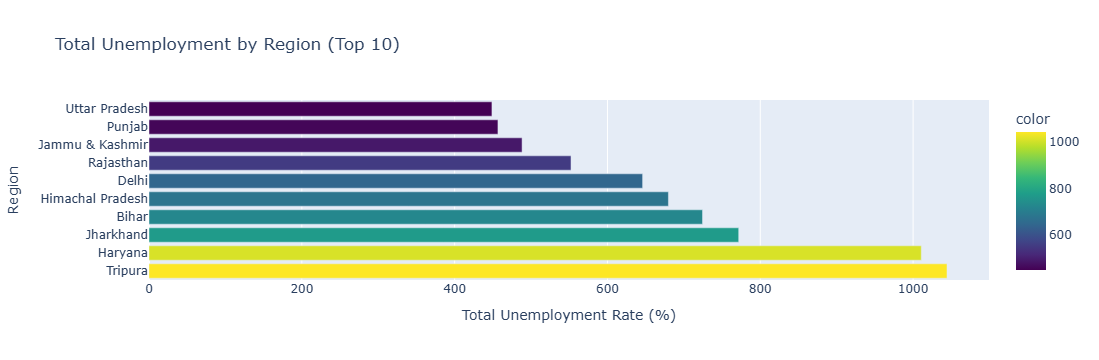

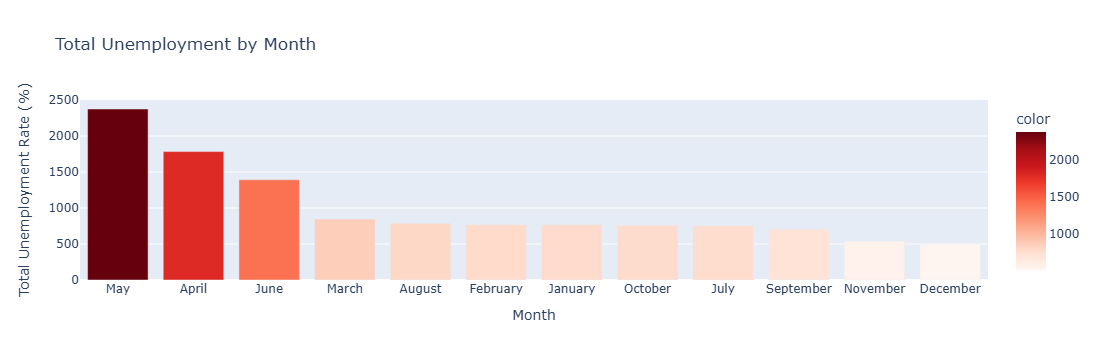

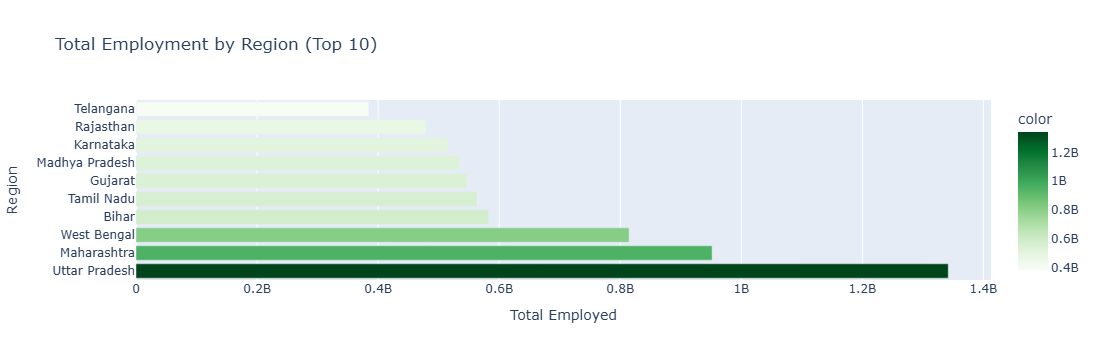

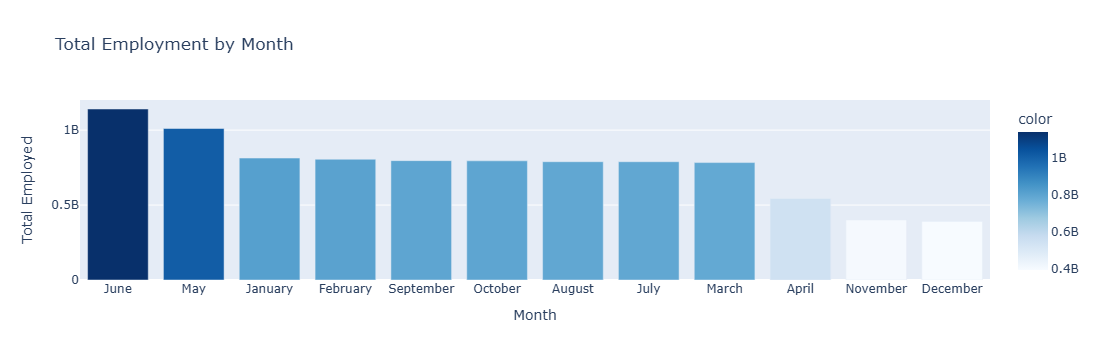

In [12]:
fig1 = px.bar(
    x=unemployment_by_region_sum.head(10).values,
    y=unemployment_by_region_sum.head(10).index,
    orientation='h',
    title='Total Unemployment by Region (Top 10)',
    labels={'x': 'Total Unemployment Rate (%)', 'y': 'Region'},
    color=unemployment_by_region_sum.head(10).values,
    color_continuous_scale='Viridis'
)
iplot(fig1)

fig2 = px.bar(
    x=unemployment_by_month_sum.index,
    y=unemployment_by_month_sum.values,
    title='Total Unemployment by Month',
    labels={'x': 'Month', 'y': 'Total Unemployment Rate (%)'},
    color=unemployment_by_month_sum.values,
    color_continuous_scale='Reds'
)
fig2.show()

fig3 = px.bar(
    x=employed_by_region_sum.head(10).values,
    y=employed_by_region_sum.head(10).index,
    orientation='h',
    title='Total Employment by Region (Top 10)',
    labels={'x': 'Total Employed', 'y': 'Region'},
    color=employed_by_region_sum.head(10).values,
    color_continuous_scale='Greens'
)
fig3.show()

fig4 = px.bar(
    x=employed_by_month_sum.index,
    y=employed_by_month_sum.values,
    title='Total Employment by Month',
    labels={'x': 'Month', 'y': 'Total Employed'},
    color=employed_by_month_sum.values,
    color_continuous_scale='Blues'
)
fig4.show()

# 10.Statistical Summary and Distribution Analysis

In [13]:
print("Statistical Summary of Unemployment Rates:")
print(combined_df['Estimated Unemployment Rate (%)'].describe())
print("\n" + "="*80 + "\n")
print("Statistical Summary of Employment:")
print(combined_df['Estimated Employed'].describe())
print("\n" + "="*80 + "\n")
print("Statistical Summary of Labour Participation Rate:")
print(combined_df['Estimated Labour Participation Rate (%)'].describe())

Statistical Summary of Unemployment Rates:
count    1007.000000
mean       11.906991
std        10.739549
min         0.000000
25%         4.685000
50%         8.890000
75%        16.125000
max        76.740000
Name: Estimated Unemployment Rate (%), dtype: float64


Statistical Summary of Employment:
count    1.007000e+03
mean     8.996209e+06
std      1.020784e+07
min      4.942000e+04
25%      1.639125e+06
50%      5.543380e+06
75%      1.287115e+07
max      5.943376e+07
Name: Estimated Employed, dtype: float64


Statistical Summary of Labour Participation Rate:
count    1007.000000
mean       42.378620
std         8.048542
min        13.330000
25%        37.835000
50%        40.880000
75%        45.315000
max        72.570000
Name: Estimated Labour Participation Rate (%), dtype: float64


# 11.Correlation Analysis Between Key Metrics

Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.209495   
Estimated Labour Participation Rate (%)                        -0.018137   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.209495   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)           -0.024770   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                        -0.018137  
Estimated Employed                                                     -0.024770  
Estimated Labour Participation Rate (%)                                 1.000000  




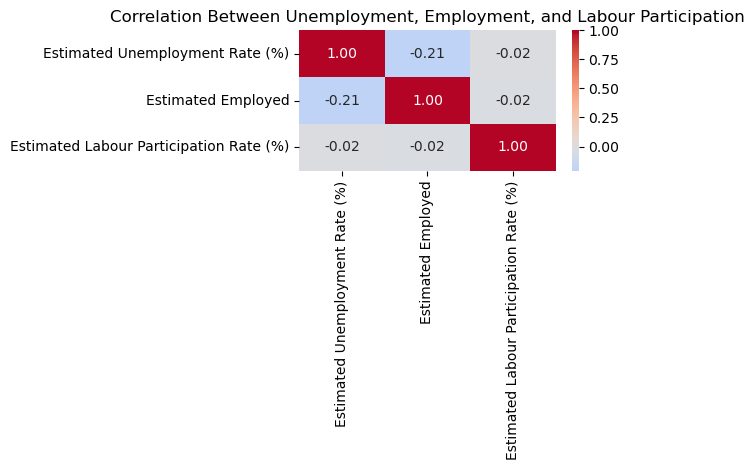

In [14]:
correlation_matrix = combined_df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr()
print("Correlation Matrix:")
print(correlation_matrix)
print("\n" + "="*80 + "\n")

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Unemployment, Employment, and Labour Participation')
plt.tight_layout()
plt.show()

# 12.Distribution Visualization with Histograms

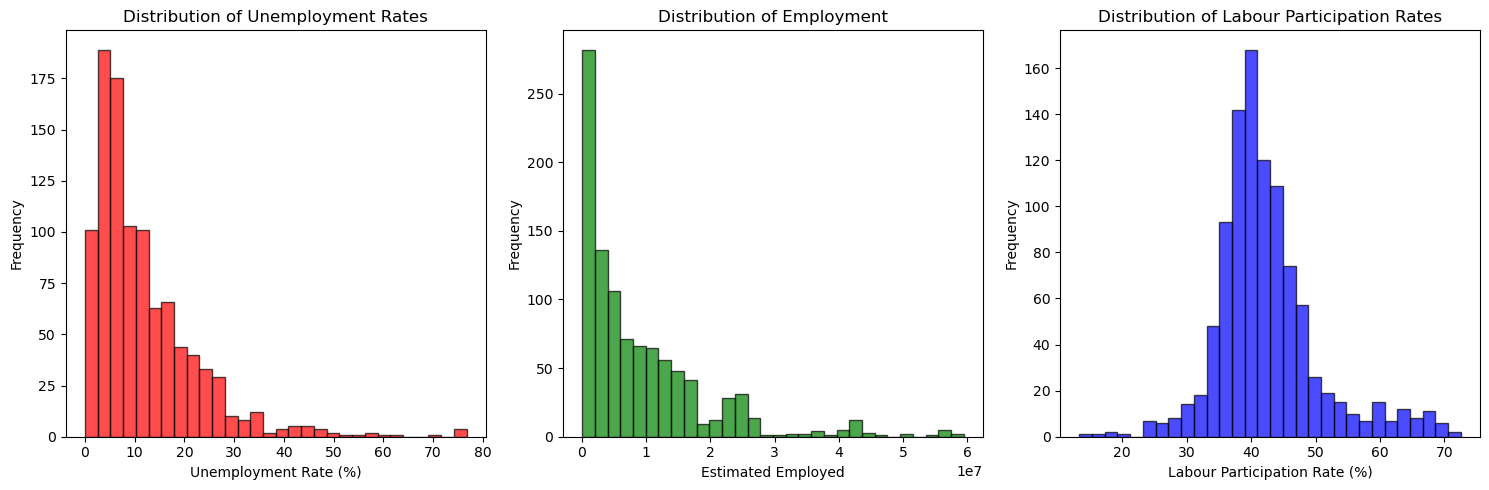

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(combined_df['Estimated Unemployment Rate (%)'], bins=30, color='red', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Unemployment Rates')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('Frequency')

axes[1].hist(combined_df['Estimated Employed'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Employment')
axes[1].set_xlabel('Estimated Employed')
axes[1].set_ylabel('Frequency')

axes[2].hist(combined_df['Estimated Labour Participation Rate (%)'], bins=30, color='blue', edgecolor='black', alpha=0.7)
axes[2].set_title('Distribution of Labour Participation Rates')
axes[2].set_xlabel('Labour Participation Rate (%)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 13.Time Series Analysis of Top Regions

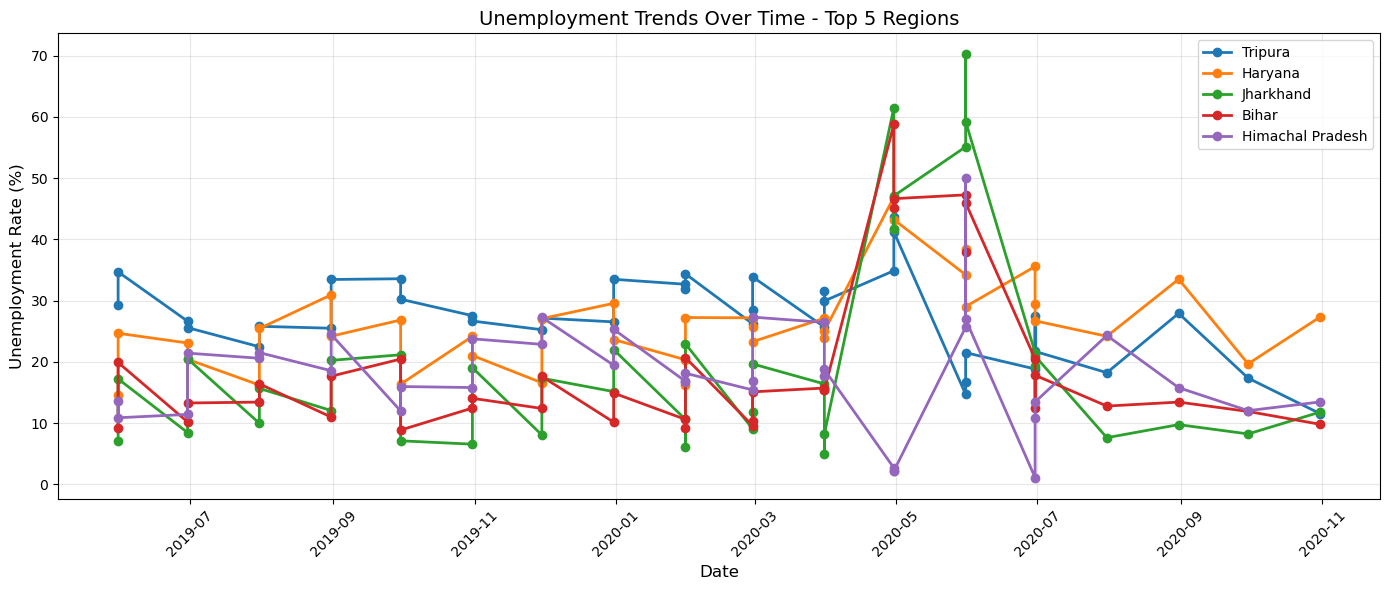

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

top_regions = unemployment_by_region_sum.head(5).index

for region in top_regions:
    region_data = combined_df[combined_df['Region'] == region].sort_values('Date')
    ax.plot(region_data['Date'], region_data['Estimated Unemployment Rate (%)'], marker='o', label=region, linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.set_title('Unemployment Trends Over Time - Top 5 Regions', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 14.Box Plot Analysis - Unemployment by Month

C:\Users\telug\AppData\Local\Temp\ipykernel_27196\4068334749.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




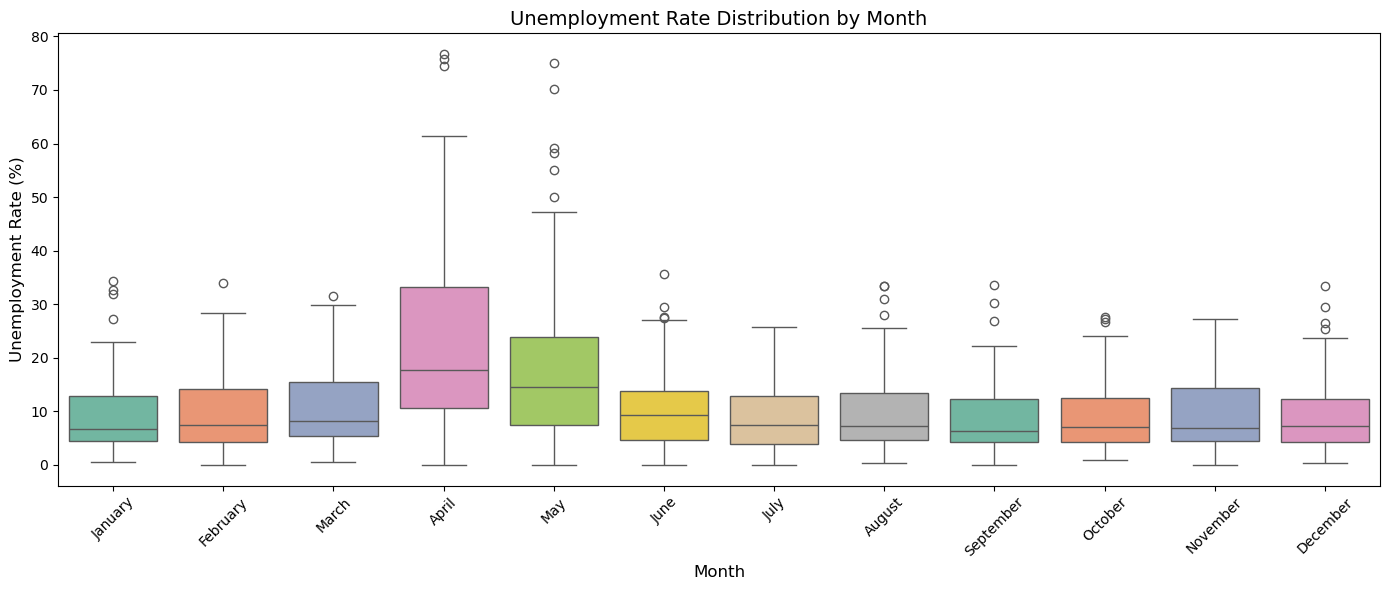

In [17]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

combined_df['Month'] = pd.Categorical(combined_df['Month'], categories=month_order, ordered=True)
combined_df_sorted = combined_df.sort_values('Month')

plt.figure(figsize=(14, 6))
sns.boxplot(data=combined_df_sorted, x='Month', y='Estimated Unemployment Rate (%)', palette='Set2')
plt.title('Unemployment Rate Distribution by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 15.Regional Comparison - Violin Plot

C:\Users\telug\AppData\Local\Temp\ipykernel_27196\2591220670.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




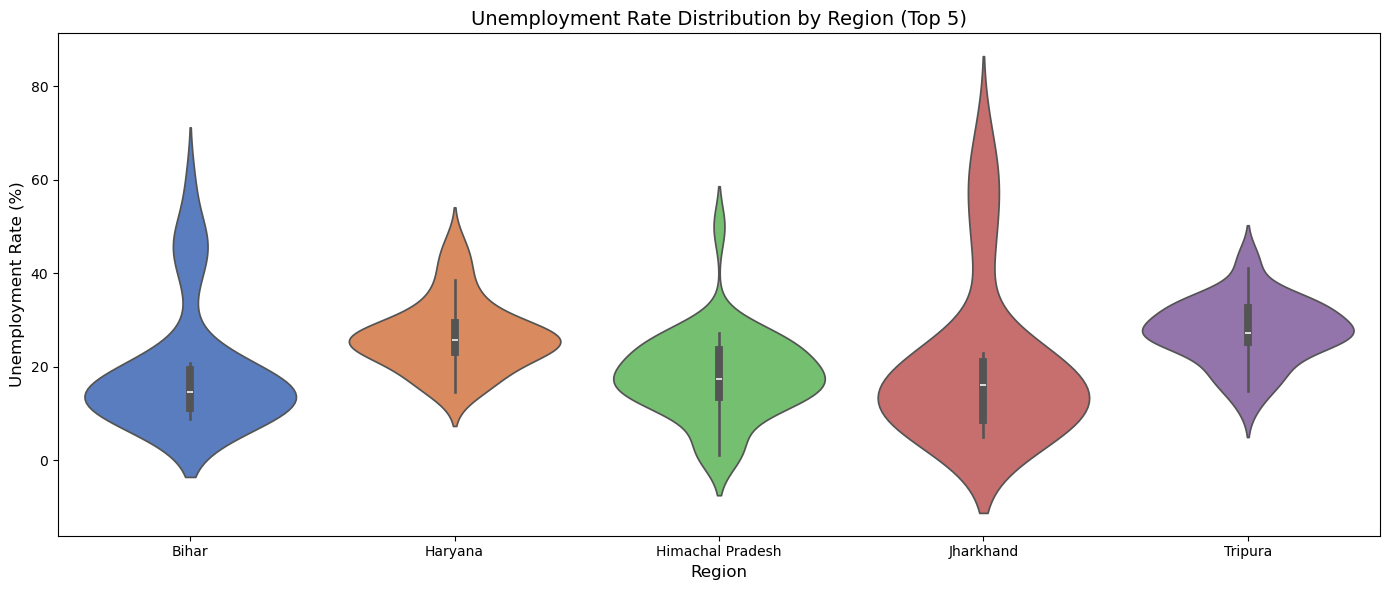

In [18]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=combined_df[combined_df['Region'].isin(top_regions)], 
               x='Region', y='Estimated Unemployment Rate (%)', palette='muted')
plt.title('Unemployment Rate Distribution by Region (Top 5)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

# 16.Scatter Plot - Employment vs Unemployment Relationship

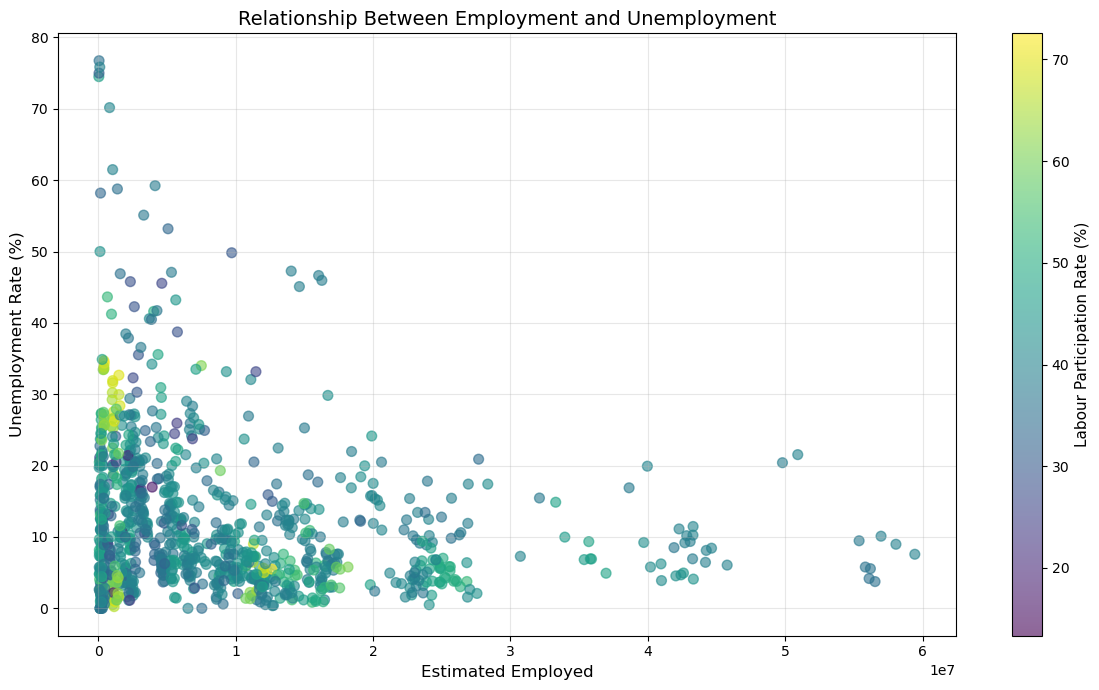

In [19]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(combined_df['Estimated Employed'], 
                     combined_df['Estimated Unemployment Rate (%)'],
                     alpha=0.6, s=50, c=combined_df['Estimated Labour Participation Rate (%)'],
                     cmap='viridis')
plt.xlabel('Estimated Employed', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.title('Relationship Between Employment and Unemployment', fontsize=14)
cbar = plt.colorbar(scatter)
cbar.set_label('Labour Participation Rate (%)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 17.Summary Statistics by Region and Area Type

Summary Statistics by Region and Area:
                       Estimated Unemployment Rate (%)                        \
                                                 count       mean        std   
Region           Area                                                          
Andhra Pradesh   Rural                              14   5.526429   4.344968   
                 Urban                              14   9.427857   8.392775   
Assam            Rural                              12   4.490833   2.096098   
                 Urban                              14   8.088571   2.692842   
Bihar            Rural                              14  16.770000  12.843814   
                 Urban                              14  21.066429  12.516503   
Chandigarh       Urban                              12  15.991667   5.508220   
Chhattisgarh     Rural                              14   6.628571   2.864434   
                 Urban                              14  11.852143   6.871595   
D

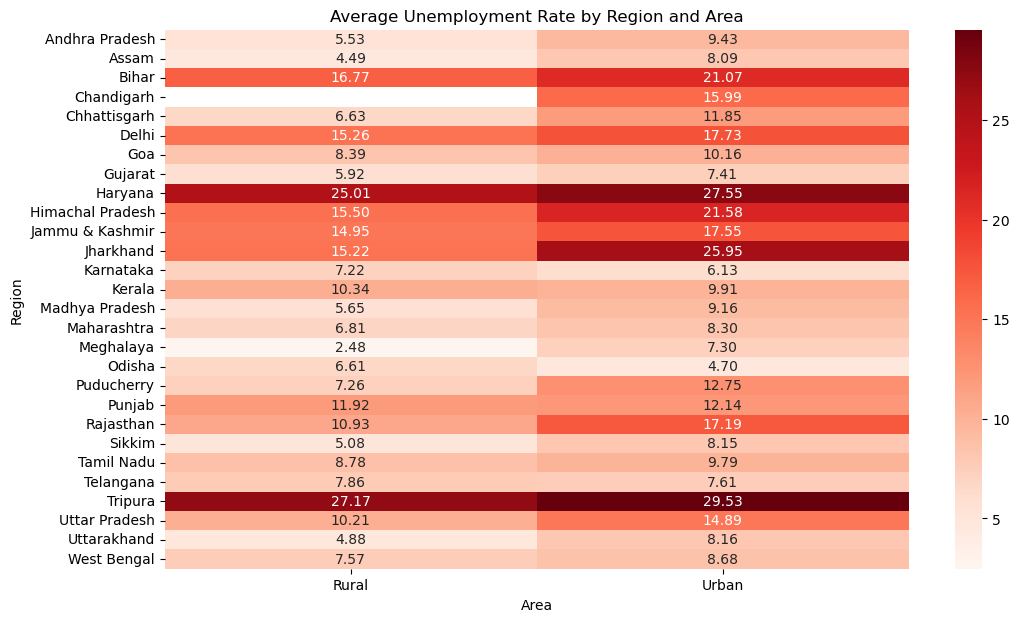

In [20]:
summary_by_region_area = combined_df.groupby(['Region', 'Area']).agg({
    'Estimated Unemployment Rate (%)': ['count', 'mean', 'std', 'min', 'max'],
    'Estimated Employed': ['mean', 'min', 'max'],
    'Estimated Labour Participation Rate (%)': ['mean']
})

print("Summary Statistics by Region and Area:")
print(summary_by_region_area.head(20))

heatmap_data = summary_by_region_area['Estimated Unemployment Rate (%)']['mean'].unstack()

plt.figure(figsize=(12,7))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Reds")

plt.title("Average Unemployment Rate by Region and Area")
plt.ylabel("Region")
plt.xlabel("Area")
plt.show()

# 18.Comparative Analysis - Rural vs Urban Unemployment

Rural vs Urban Unemployment Comparison:
      Estimated Unemployment Rate (%)                                    \
                                count       mean        std  min    max   
Area                                                                      
Rural                             359  10.324791  10.038895  0.0  74.51   
Urban                             381  13.166614  11.165444  0.0  76.74   

      Estimated Employed Estimated Labour Participation Rate (%)  
                    mean                                    mean  
Area                                                              
Rural       1.019285e+07                               44.464819  
Urban       4.388626e+06                               40.901365  




<Figure size 1000x600 with 0 Axes>

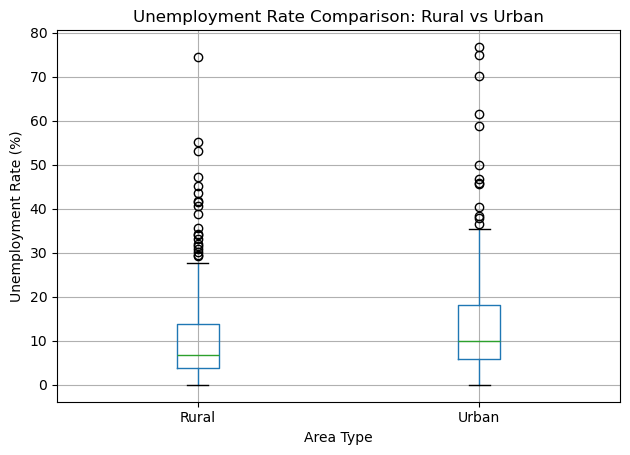

In [21]:
rural_urban_comparison = combined_df.groupby('Area').agg({
    'Estimated Unemployment Rate (%)': ['count', 'mean', 'std', 'min', 'max'],
    'Estimated Employed': ['mean'],
    'Estimated Labour Participation Rate (%)': ['mean']
})

print("Rural vs Urban Unemployment Comparison:")
print(rural_urban_comparison)
print("\n" + "="*80 + "\n")

plt.figure(figsize=(10, 6))
combined_df.boxplot(column='Estimated Unemployment Rate (%)', by='Area')
plt.title('Unemployment Rate Comparison: Rural vs Urban')
plt.suptitle('')
plt.xlabel('Area Type')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

# 19.Key Findings and Conclusions

## Main Insights from the Analysis:¶
1. **Regional Disparities**: Certain states (Tripura, Haryana, Jharkhand) show significantly higher unemployment rates compared to others, indicating regional labor market imbalances.

2. **Seasonal Patterns**: Unemployment exhibits clear seasonal trends, with peaks typically occurring in April-May (post-fiscal year transition) and lower rates in other periods.

3. **COVID-19 Impact**: The 2020 data shows a dramatic spike in unemployment in April 2020 (lockdown period), demonstrating the pandemic's severe impact on employment.

4. **Employment-Unemployment Relationship**: While inverse relationships exist between employment and unemployment, the correlation is not perfect, suggesting labor force participation changes influence both metrics.

5. **Rural vs Urban**: The analysis reveals different unemployment dynamics between rural and urban areas, with potential structural differences in labor markets.

6. **Labour Participation**: States with higher labor participation rates show different unemployment patterns, indicating workforce engagement affects employment outcomes.

## Recommendations:¶
* Focus policy interventions on high-unemployment regions for targeted economic development
* Develop seasonal employment programs to address cyclical unemployment
* Strengthen labor market information systems in rural areas
* Create region-specific skill development and training programs